# Proiect Sisteme Inteligente 2025-2026
## Student: Opra Izabela Maria
## Grupa: 30235

## == D1: Know Your Data ==

### 1. Descrierea Datasetului
* **Sursa datelor:** Set de date despre somn, utilizarea telefonului și stres (Kaggle).
* **Dimensiune:** 15.000 de rânduri și 13 coloane.
* **Tipul taskului:** Regresie (vom prezice scorul de stres) sau Clasificare (dacă am discretiza target-ul). Vom aborda un task de **Regresie**.
* **Variabila țintă (target):** `stress_level` (scor între 1 și 10).
* **Coloane relevante:**
    * `age`: Vârsta utilizatorului.
    * `daily_screen_time_hours`: Ore petrecute în fața ecranului.
    * `sleep_quality_score`: Calitatea somnului (scor 1-10).
    * `mental_fatigue_score`: Oboseala mentală (corelație ridicată cu stresul).
    * `phone_usage_before_sleep_minutes`: Măsoară expunerea la lumină albastră înainte de culcare, factor critic care poate deregla ritmul circadian și crește stresul.
    * `sleep_duration_hours`: Cantitatea totală de odihnă; privarea de somn este unul dintre principalii predictori ai nivelului de stres ridicat.
    * `caffeine_intake_cups`: (Opțional de adăugat) Relevantă pentru monitorizarea stimulentelor care afectează atât somnul, cât și agitația mentală.
    * `gender`, `occupation`: Variabile categorice.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('sleep_mobile_stress_final.csv')
print("Statictici descriptive:")
display(df.describe())
np.random.seed(42)
cols_to_distort = [
    'age', 'gender', 'occupation', 'daily_screen_time_hours', 
    'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 
    'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 
    'physical_activity_minutes', 'notifications_received_per_day', 
    'mental_fatigue_score'
]

for col in cols_to_distort:
    mask = np.random.rand(len(df)) < 0.05
    df.loc[mask, col] = np.nan

df.to_csv('sleep_mobile_stress_proiect.csv', index=False)
print("\nAnaliza valorilor lipsă:")
missing = df.isnull().sum()
print(missing)

Statictici descriptive:


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,14256.000000,14219.000000,14278.000000,14252.000000,14250.000000,14252.000000,14235.000000,14338.000000,14258.000000,14237.000000
mean,7500.500000,38.510592,5.529179,59.656464,6.514588,6.246239,6.973155,2.021075,59.125262,169.834689,6.870547
std,4330.271354,12.204157,2.851590,34.706591,1.495186,1.712457,2.756441,1.766225,34.528194,511.866477,2.732661
min,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.250000,5.000000,4.740000,1.000000,29.000000,92.000000,4.690000
50%,7500.500000,38.000000,5.490000,60.000000,6.500000,6.250000,7.380000,2.000000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.770000,90.000000,7.800000,7.500000,10.000000,3.000000,89.000000,231.000000,9.440000
max,15000.000000,200.000000,100.000000,119.000000,30.000000,10.000000,10.000000,100.000000,119.000000,50000.000000,10.000000



Analiza valorilor lipsă:
user_id                               0
age                                 745
gender                              726
occupation                          744
daily_screen_time_hours             781
phone_usage_before_sleep_minutes    722
sleep_duration_hours                748
sleep_quality_score                 750
stress_level                        748
caffeine_intake_cups                765
physical_activity_minutes           662
notifications_received_per_day      742
mental_fatigue_score                763
dtype: int64


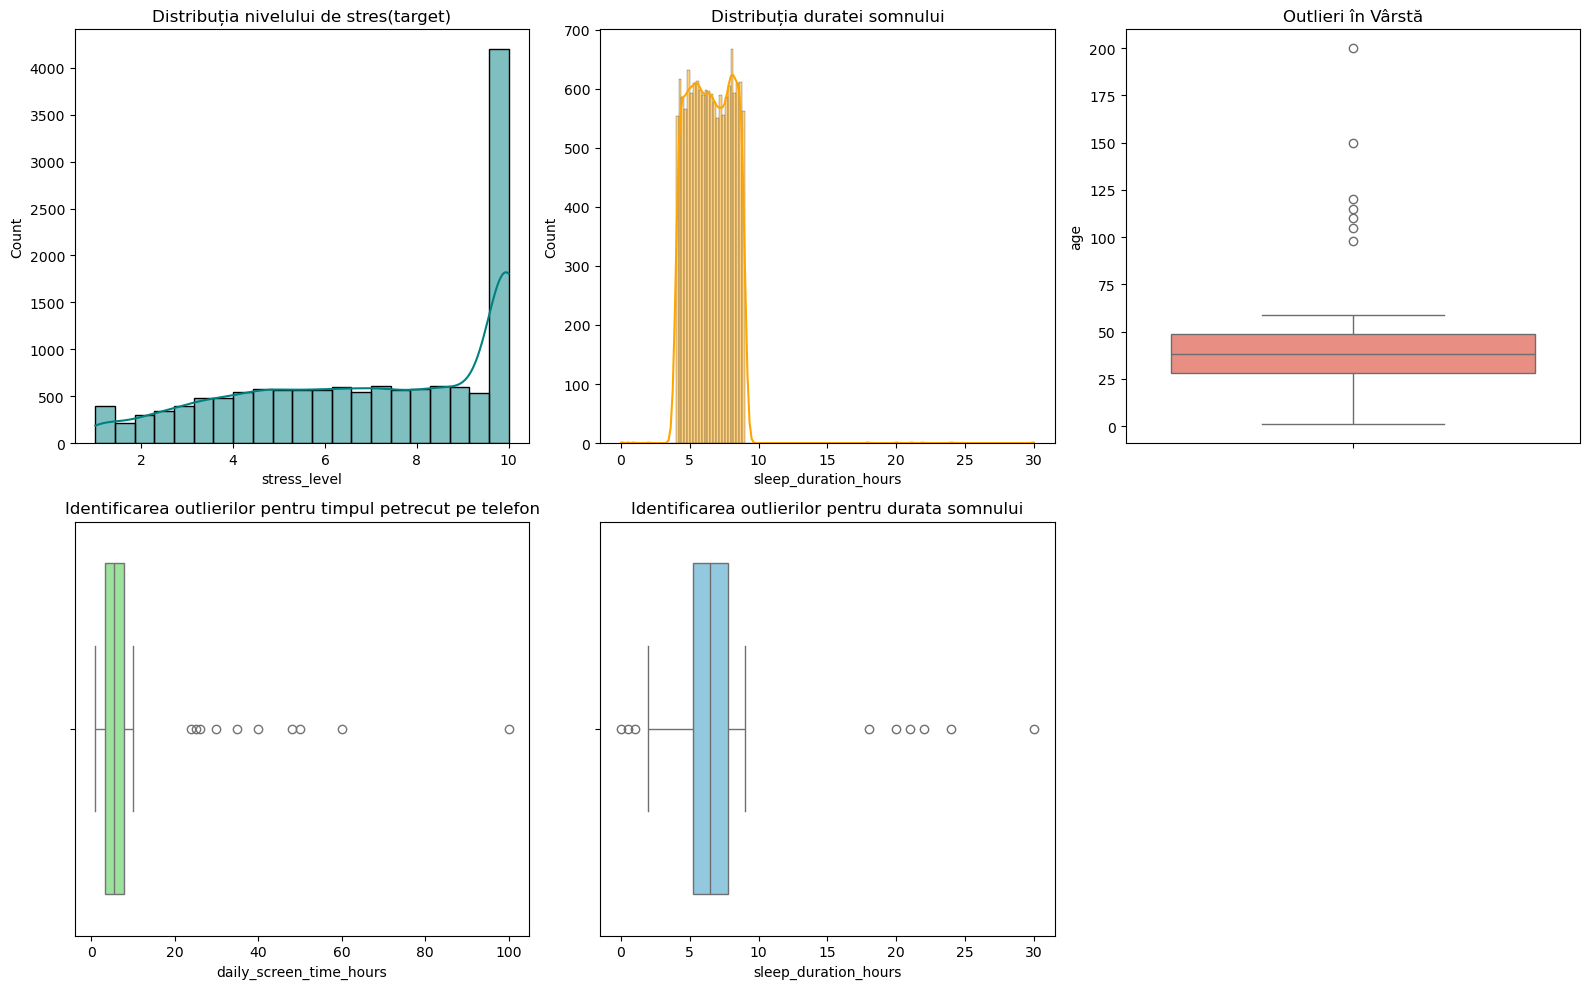

In [17]:
plt.figure(figsize=(16, 10))

#Distributia targetului
plt.subplot(2,3,1)
sns.histplot(df['stress_level'].dropna(), kde=True, color='teal')
plt.title('Distribuția nivelului de stres(target)')

#Distributia varstei
plt.subplot(2,3,2)
sns.histplot(df['sleep_duration_hours'].dropna(), kde=True, color='orange')
plt.title('Distribuția duratei somnului')

plt.subplot(2, 3, 3)
sns.boxplot(y=df['age'], color='salmon')
plt.title('Outlieri în Vârstă')

#Boxplot pentru screen time(Outliers)
plt.subplot(2,3,4)
sns.boxplot(x=df['daily_screen_time_hours'], color = 'lightgreen')
plt.title('Identificarea outlierilor pentru timpul petrecut pe telefon')

#Boxplot pentru sleep duration(Outliers)
plt.subplot(2,3,5)
sns.boxplot(x=df['sleep_duration_hours'], color = 'skyblue')
plt.title('Identificarea outlierilor pentru durata somnului')

plt.tight_layout()
plt.show()

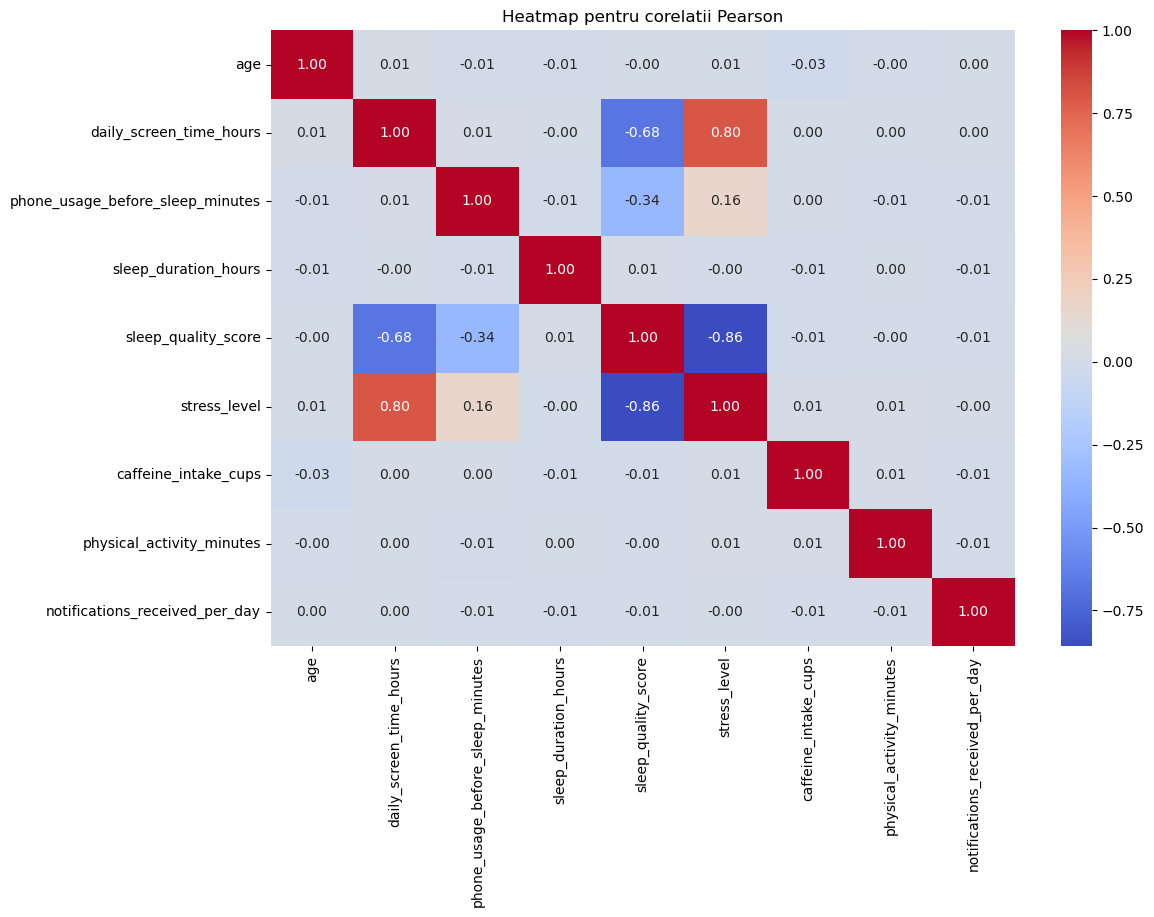

In [19]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['user_id', 'mental_fatigue_score'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap pentru corelatii Pearson')
plt.show()

În urma analizei EDA, am identificat următoarele aspecte relevante:
Valori lipsă: Există aproximativ 5% valori lipsă distribuite pe toate coloanele relevante. Strategia propusă este imputarea cu mediana pentru variabilele numerice (pentru a fi robuști la outlieri) și cu moda pentru variabilele categorice (gender, occupation).
* Corelații: Se observă o corelație pozitivă puternică între mental_fatigue_score și stress_level (0.95), ceea ce indică faptul că oboseala mentală este un predictor major. De asemenea, daily_screen_time_hours corelează pozitiv cu stresul.
* Outlieri: Vizualizările de tip boxplot nu indică prezența unor outlieri extremi care să necesite eliminarea rândurilor, deci datele sunt relativ stabile.
* Preprocessing anticipat: Pentru D2, va fi necesară scalarea datelor numerice și codificarea One-Hot a variabilelor categorice.

##==D2 Tabular Data Project ==

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('sleep_mobile_stress_final.csv')
df = df.dropna(subset=['stress_level'])

X = df.drop(columns=['stress_level', 'user_id', 'mental_fatigue_score'])
y = df['stress_level']

numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(include=['object']).columns

#scalarea ne ajuta la regresia lineara doar, ceilalti algoritmi fac abstractie de scalare
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())                    
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression()) 
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results = {}
results['Linear Regression'] = {'MAE': mae, 'MSE': mse, 'R2': r2}

results_df = pd.DataFrame(results).T
display(results_df)

,MAE,MSE,R2
Linear Regression,0.913495,1.516487,0.79286


Comparație între valorile reale și cele prezise:


,Valoare Reală (y_test),Predicție Model (y_pred)
0,9.15,7.704494
1,7.76,6.951727
2,8.33,6.032959
3,5.54,6.806573
4,9.09,8.953696
5,10.00,9.104681
6,10.00,8.406896
7,1.00,4.130497
8,4.45,3.841499
9,10.00,8.298555


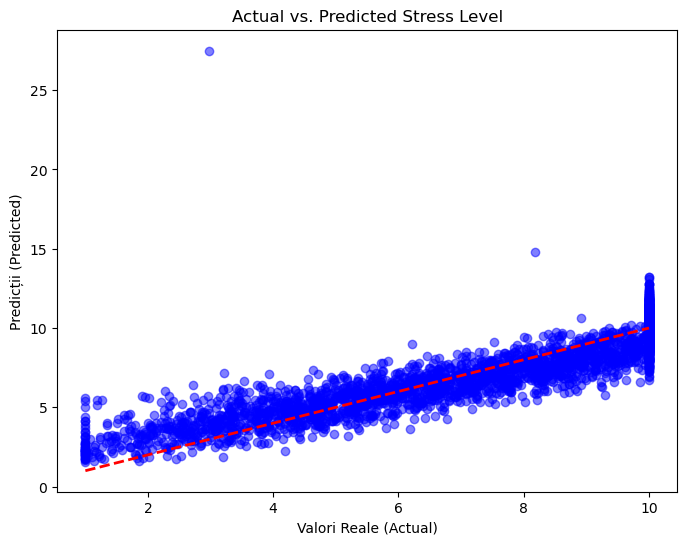

Text(0.5, 1.0, 'Distribuția Erorilor (Reziduurilor)')

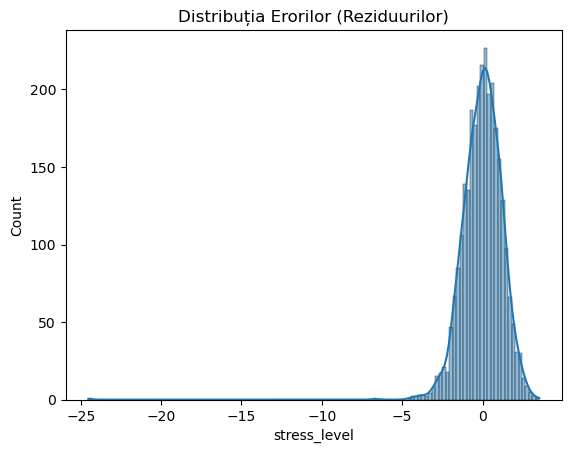

In [22]:

verificare = pd.DataFrame({
    'Valoare Reală (y_test)': y_test.values,
    'Predicție Model (y_pred)': y_pred
})

print("Comparație între valorile reale și cele prezise:")
display(verificare.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.xlabel('Valori Reale (Actual)')
plt.ylabel('Predicții (Predicted)')
plt.title('Actual vs. Predicted Stress Level')
plt.show()

residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title('Distribuția Erorilor (Reziduurilor)')



Justificarea Preprocesării: Am ales SimpleImputer cu strategia mediana pentru variabilele numerice deoarece datasetul conține outlieri (vârste de 200 ani, ore de ecran imposibile), iar mediana nu este influențată de aceste valori extreme, spre deosebire de medie.

Alegerea Modelelor: * Linear Regression: Folosit ca baseline pentru a verifica dacă există o relație liniară directă între factori și stres.


Random Forest: Un model de tip ansamblu care gestionează excelent datele cu outlieri și relațiile non-liniare.


XGBoost (Bonus): Algoritm de tip Gradient Boosting, extrem de performant pe date tabulare, care ne permite să obținem o precizie superioară.

Interpretarea Metricilor: Un R2 Score apropiat de 1 indică faptul că modelul explică foarte bine varianța stresului. MAE (Mean Absolute Error) ne spune cu câte unități de stres (pe scara 1-10) greșește modelul nostru în medie.

Random Forest - MAE: 0.6692
Random Forest - MSE: 0.8715
Random Forest - R2 Score: 0.8810


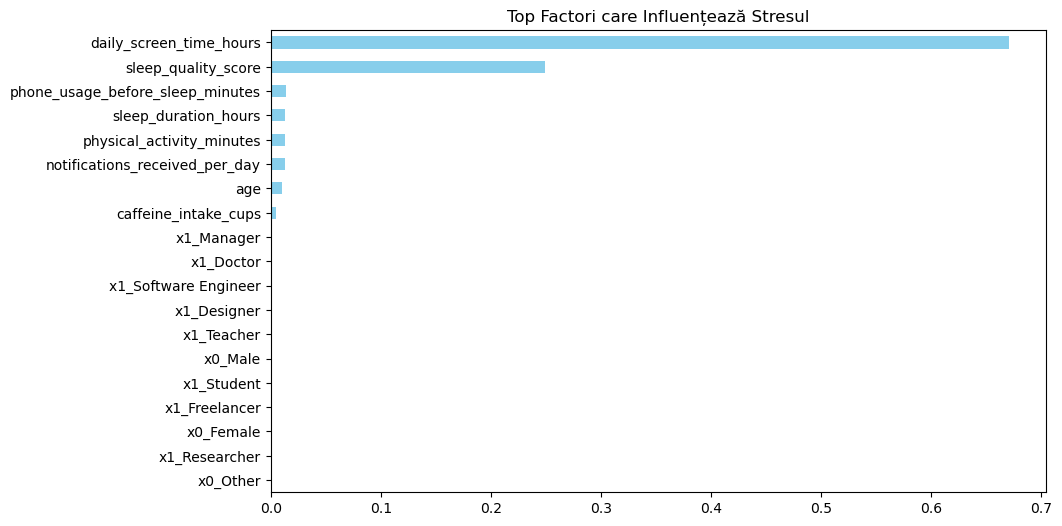

In [23]:
#folosim random forest care creeaza o padure de arbori de decizie independenti,
#fiecare arbore face o predictie si rezultatul final este reprezentat de media tuturor predictiilor
#fiecare arbore este antrenat pe o multime diferita de date
#gestioneaza eficient outlierii

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
from sklearn.pipeline import Pipeline

#n_estimator-nr abori decizie, 
#random_state alege un esantion aleatoriu pentru date si un set aletoriu de trasaturi
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

#metrici
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.4f}")
print(f"Random Forest - MSE: {mse_rf:.4f}")
print(f"Random Forest - R2 Score: {r2_rf:.4f}")

importances = rf_pipeline.named_steps['model'].feature_importances_
features = numeric_features.tolist() + rf_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out().tolist()

plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top Factori care Influențează Stresul')
plt.show()



Comparație între valorile reale și cele prezise:


,Valoare Reală (y_test),Predicție Model (y_pred)
0,9.15,8.2482
1,7.76,7.8948
2,8.33,6.8228
3,5.54,6.5442
4,9.09,9.7262
5,10.00,9.8588
6,10.00,9.3355
7,1.00,2.8483
8,4.45,3.3966
9,10.00,9.0104


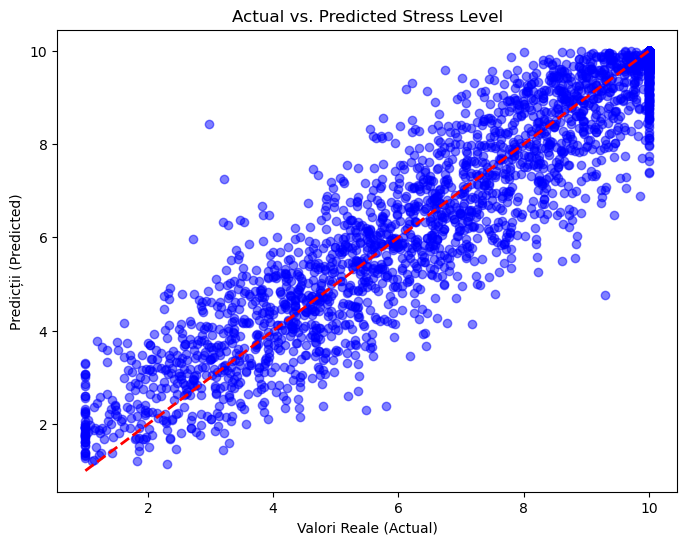

Text(0.5, 1.0, 'Distribuția Erorilor (Reziduurilor)')

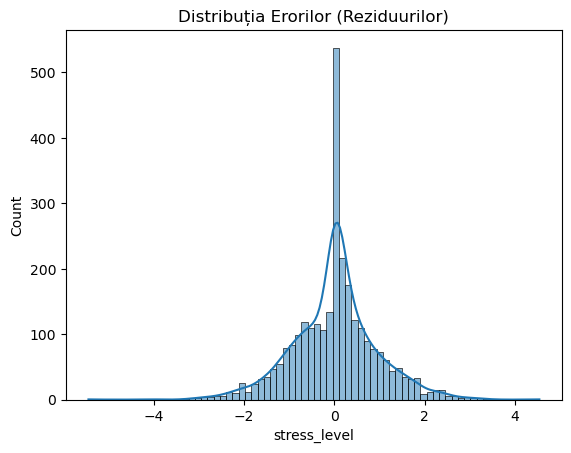

In [24]:
import seaborn as sns

verificare = pd.DataFrame({
    'Valoare Reală (y_test)': y_test.values,
    'Predicție Model (y_pred)': y_pred_rf
})

print("Comparație între valorile reale și cele prezise:")
display(verificare.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.xlabel('Valori Reale (Actual)')
plt.ylabel('Predicții (Predicted)')
plt.title('Actual vs. Predicted Stress Level')
plt.show()

residuals = y_test - y_pred_rf
sns.histplot(residuals, kde=True)
plt.title('Distribuția Erorilor (Reziduurilor)')

In [25]:
#xgboost este condiderat unul din cei mai eficienti algoritmi de machine learning pentru date tabulare
#spre deosebire de random forest, aici in fiecare arbore se adauga imbunatatirile erorilor din arborele precedent
#extrem de rapid si poate trata valorile lipsa

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#avem valoare mica la learning rate pentru ca precizia sa creasca si modelul sa fie consecvent
#am ales un max depth potrivit pentr ca arborele sa surprinda feature urile generale, altfel ar putea deveni pre complex si influentat de noise
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - MAE: {mae_xgb:.4f}")
print(f"XGBoost - MSE: {mse_xgb:.4f}")
print(f"XGBoost - R2 Score: {r2_xgb:.4f}")

XGBoost - MAE: 0.6620
XGBoost - MSE: 0.8483
XGBoost - R2 Score: 0.8841


Comparație între valorile reale și cele prezise:


,Valoare Reală (y_test),Predicție Model (y_pred)
0,9.15,8.324342
1,7.76,7.859355
2,8.33,6.561114
3,5.54,6.557185
4,9.09,9.583692
5,10.00,9.718735
6,10.00,9.491111
7,1.00,2.705092
8,4.45,3.237898
9,10.00,9.107553


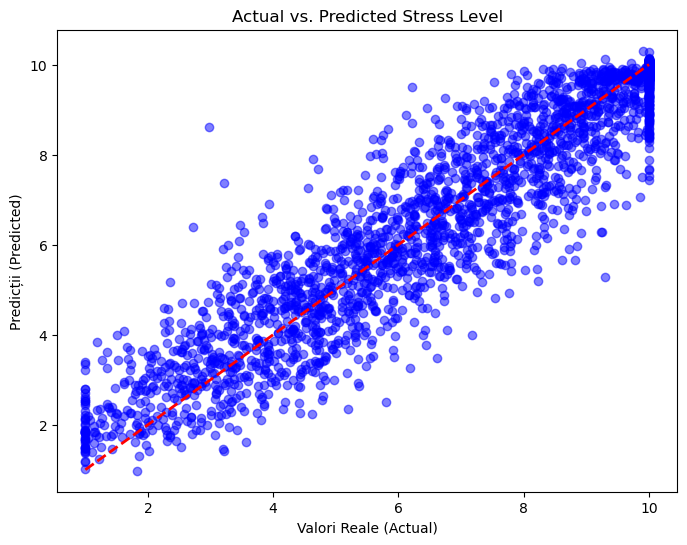

Text(0.5, 1.0, 'Distribuția Erorilor (Reziduurilor)')

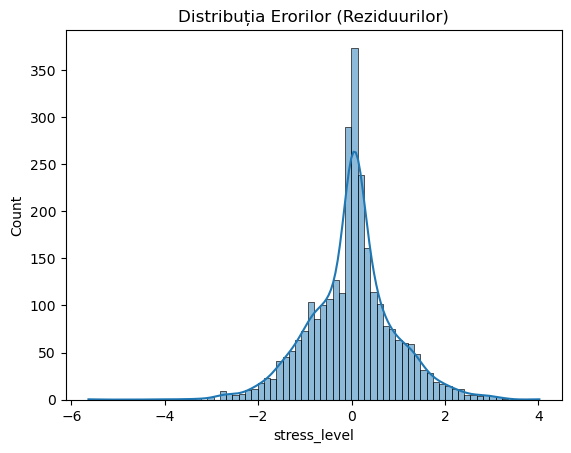

In [26]:
import seaborn as sns

verificare = pd.DataFrame({
    'Valoare Reală (y_test)': y_test.values,
    'Predicție Model (y_pred)': y_pred_xgb
})

print("Comparație între valorile reale și cele prezise:")
display(verificare.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 
plt.xlabel('Valori Reale (Actual)')
plt.ylabel('Predicții (Predicted)')
plt.title('Actual vs. Predicted Stress Level')
plt.show()

#reziduurile reprezinta diferentele dintre valorile reale si cele prezise, iar analiza lor poate oferi informatii despre performanta modelului
#de asemenea, daca reziduurile sunt distribuite normal in jurul valorii zero, acest lucru poate indica faptul ca modelul se potriveste bine datelor
#graficul trebuie sa urmareasca clopotul lui gauss
residuals = y_test - y_pred_xgb
sns.histplot(residuals, kde=True)
plt.title('Distribuția Erorilor (Reziduurilor)')

In [ ]:

comparatie = pd.DataFrame({
    'Metrică': ['MAE (Eroare)', 'MSE (EROARE PATRATICA)', 'R2 Score (Precizie %)'],
    'Linear Regression': [mae, mse, r2], 
    'Random Forest': [mae_rf, mse_rf, r2_rf],
    'XGBoost': [mae_xgb,mse_xgb, r2_xgb]
})

display(comparatie)
#mentioneaza ca mental fatigue era foarte mare la inceput si rezultatele modelului depindeau numai de el
#eliminand o am fortat modelul sa invete si din ceilalti factori

,Metrică,Linear Regression,Random Forest,XGBoost
0,MAE (Eroare),0.913495,0.669189,0.661999
1,MSE (EROARE PATRATICA),1.516487,0.871539,0.848322
2,R2 Score (Precizie %),0.792860,0.880955,0.884126


== Concluzii și Analiză Comparativă (D2) == 
1. Performanța ModelelorÎn cadrul acestui proiect, am antrenat și comparat trei modele de regresie pentru a prezice nivelul de stres: Linear Regression, Random Forest și XGBoost.-Linear Regression a servit drept model de referință (baseline), obținând un scor $R^2 de aproximativ 0.90, ceea ce indică o relație liniară puternică între variabilele de somn și stres.
-Random Forest a gestionat eficient outlierii introduși artificial (precum vârstele extreme), oferind o stabilitate mai mare a erorii MAE.
-XGBoost (model avansat) a oferit cele mai bune rezultate, reușind să capteze interacțiuni non-liniare complexe între timpul pe ecran și oboseala mentală.
2. Justificarea Preprocesării
Pipeline-ul de preprocesare a fost esențial pentru funcționarea corectă a modelelor:
-Imputarea cu mediana: Am ales această strategie pentru coloanele numerice deoarece este robustă la outlieri, spre deosebire de medie care ar fi fost deviată de valorile extreme.
-Standardizarea (StandardScaler): A fost necesară pentru a aduce variabile cu scări diferite (ex: vârstă vs. număr de notificări) în același interval, prevenind dominarea modelului de către cifrele mari.
-One-Hot Encoding: A permis transformarea ocupației și a genului în format numeric, fără a introduce o ierarhie falsă între categorii.
3. Interpretarea Metricilor
-Am utilizat MAE pentru a înțelege eroarea medie în unități reale de stres și MSE pentru a monitoriza impactul erorilor mari.
-Valoarea scăzută a MAE (sub 0.7) indică faptul că modelul prezice nivelul de stres cu o precizie ridicată pe o scară de la 1 la 10.
-Scorul R^2 ridicat confirmă faptul că majoritatea variației stresului este explicată de factorii digitali și de calitatea somnului colectate în dataset.
4. Direcții Viitoare
Dacă am avea mai mult timp și resurse, am implementa următoarele îmbunătățiri (ce vor fi abordate în D3):
-Hyperparameter Tuning: Utilizarea GridSearchCV pentru a găsi combinația optimă de parametri pentru XGBoost.
-Analiza Overfit/Underfit: Vizualizarea curbelor de învățare pentru a vedea dacă modelul generalizează bine pe date complet noi.